Imports

In [1]:
import json
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from PIL import Image

Load vocab

In [2]:
with open('../src/vocab.json') as f:
    vocab = json.load(f)

stoi = vocab['stoi']
itos = {int(k): v for k, v in vocab['itos'].items()}   

PAD, BOS, EOS = 0, 1, 2
vocab_size = len(stoi) - 3 + 3  
print(vocab_size)

39


Load labels

In [3]:
paths, labels = [], []
with open("../data/synth/train/labels.txt") as f:
    for line in f:
        fname, label = line.strip().split("\t")
        paths.append(f"../data/synth/train/{fname}")
        labels.append(label)

print(len(paths), paths[0], labels[0])

500 ../data/synth/train/00000.png 0t2be1yq


Transform

In [4]:
transform = T.Compose([
    T.Resize((32, 128)),
    T.Grayscale(),
    T.ToTensor(),
    T.Normalize(mean=[0.5], std=[0.5]),
])

Dataset class

In [5]:
class OCRDataset(Dataset):
    def __init__(self, image_paths, labels, transform, stoi):
        self.paths = image_paths
        self.labels = labels
        self.transform = transform
        self.stoi = stoi

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert('RGB')
        img = self.transform(img)
        label = self.labels[idx].lower()
        label_ids = [self.stoi[c] for c in label if c in self.stoi]
        return img, label_ids

Collate function

In [7]:
def collate_fn(batch):
    imgs, label_lists = zip(*batch)
    imgs = torch.stack(imgs)

    max_len = max(len(l) for l in label_lists) + 1   # +1 for EOS
    tgt_in  = torch.full((len(batch), max_len), PAD, dtype=torch.long)
    tgt_out = torch.full((len(batch), max_len), PAD, dtype=torch.long)

    for i, ids in enumerate(label_lists):
        seq = [BOS] + ids
        tgt_in[i, :len(seq)] = torch.tensor(seq)
        out = ids + [EOS]
        tgt_out[i, :len(out)] = torch.tensor(out)

    return imgs, tgt_in, tgt_out

Build dataset + dataloader

In [8]:
ds = OCRDataset(paths, labels, transform, stoi)
loader = DataLoader(ds, batch_size=4, collate_fn=collate_fn, shuffle=True)

imgs, tgt_in, tgt_out = next(iter(loader))
print(imgs.shape)      # expect [4, 1, 32, 128]
print(tgt_in.shape)    # expect [4, max_len]
print(tgt_in[0])
print(tgt_out[0])

torch.Size([4, 1, 32, 128])
torch.Size([4, 12])
tensor([ 1, 35, 27, 30, 24, 16,  0,  0,  0,  0,  0,  0])
tensor([35, 27, 30, 24, 16,  2,  0,  0,  0,  0,  0,  0])


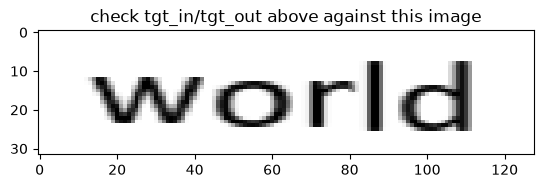

decoded label: world


In [9]:
import matplotlib.pyplot as plt

img = imgs[0, 0] * 0.5 + 0.5   # undo normalization for display
plt.imshow(img, cmap='gray')
plt.title(labels[0] if False else "check tgt_in/tgt_out above against this image")
plt.show()

decoded = ''.join(itos[i.item()] for i in tgt_out[0] if i.item() not in (PAD, BOS, EOS))
print("decoded label:", decoded)